In [1]:
using Serialization
using Plots

res0 = deserialize("../examples/sia/runs/solution_0res.jls");
res1 = deserialize("../examples/sia/runs/solution_1res.jls");
res2 = deserialize("../examples/sia/runs/solution_2res.jls");

# data  = x, h_list, t_list, dt_list, f_list
x0 = res0[1]
h0 = res0[2]
t0 = res0[3]

x1 = res1[1]
h1 = res1[2]
t1 = res1[3]

x2 = res2[1]
h2 = res2[2]
t2 = res2[3]

println(length(t0))
println(length(t1))
println(length(t2))


2
3
5


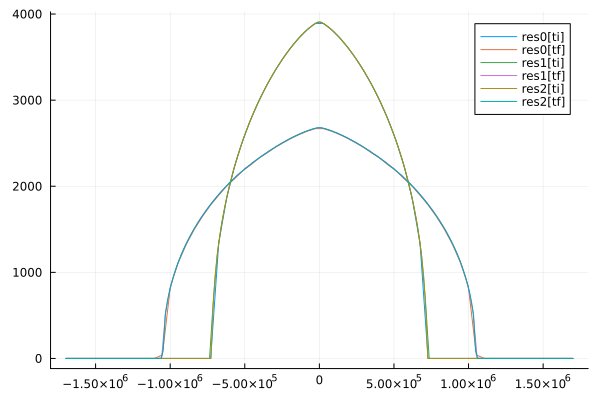

In [2]:
plot(x0, h0[1], label="res0[ti]")
plot!(x0, h0[end], label="res0[tf]")

plot!(x1, h1[1], label="res1[ti]")
plot!(x1, h1[end], label="res1[tf]")

plot!(x2, h2[1], label="res2[ti]")
plot!(x2, h2[end], label="res2[tf]")

In [3]:
# analytical solution
function Halfar(t,x)
    # copied from https://github.com/bueler/karthaus/blob/master/mfiles/halfar.m
    g = 9.81     # constants in SI units
    rho = 910.0
    secpera = 365*24*3600 # seconds per one year
    n = 3
    A = 1.0e-16/secpera
    Gamma  = 2.0 * A * (rho * g)^3 / 5.0 # see Bueler et al (2005)

    H0 = 3600.0
    R0 = 750.0e3
    alpha = 1/9#0.1111111111111111
    beta = 1/18#0.05555555555555555
    # for t0, see equation (9) in Bueler et al (2005); result is 422.45 a:
    t0 = (beta/Gamma) * (7/4)^3 * (R0^4/H0^7)

    #r = sqrt(x.*x + y.*y)
    #r = r / R0
    # retrict in x only
    x = x / R0
    t = t / t0
    N = length(x)
    inside = zeros(N)
    for i in 1:N
        test = 1.0 - (abs(x[i]) / t^beta)^((n+1) / n)
        if test > 0
            inside[i] = test
        end # if
    end # for
    H = H0 .* inside.^(n / (2*n+1)) / t^alpha
    return H
end

Halfar (generic function with 1 method)

In [4]:
hi = Halfar(t0[1], x0)

tf0 = t0[end]
hf0 = Halfar(tf0, x0)

tf1 = t1[end]
hf1 = Halfar(tf1, x1)

tf2 = t2[end]
hf2 = Halfar(tf2, x2)

256-element Vector{Float64}:
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 ⋮
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0
 0.0

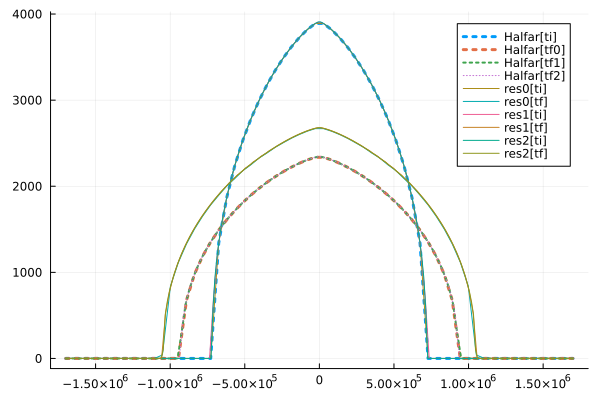

In [5]:
plot(x0, hi, label="Halfar[ti]", linewidth = 3, linestyle = :dot)
plot!(x0, hf0, label="Halfar[tf0]", linewidth = 3, linestyle = :dot)
plot!(x1, hf1, label="Halfar[tf1]", linewidth = 2, linestyle = :dot)
plot!(x2, hf2, label="Halfar[tf2]", linewidth = 1, linestyle = :dot)

plot!(x0, h0[1], label="res0[ti]")
plot!(x0, h0[end], label="res0[tf]")

plot!(x1, h1[1], label="res1[ti]")
plot!(x1, h1[end], label="res1[tf]")

plot!(x2, h2[1], label="res2[ti]")
plot!(x2, h2[end], label="res2[tf]")

In [6]:
t0[end]-t1[end]
t1[end] - t2[end]

0.0

In [7]:
function average_height_error(Halfar, model)
    error = Halfar - model
    error = abs.(error)
    error = sum(error)/length(model)
    return error
end

err0 = average_height_error(hf0, h0[end])
err1 = average_height_error(hf1, h1[end])
err2 = average_height_error(hf2, h2[end])

println("err0 = ", err0)
println("err1 = ", err1)
println("err2 = ", err2)


err0 = 270.9040105605109
err1 = 277.941770822367
err2 = 278.46535328574885


In [8]:
dx0 = x0[end] - x0[end-1]
dx1 = x1[end] - x1[end-1]
dx2 = x2[end] - x2[end-1]

R = (dx0-dx1)/(dx1-dx2)

2.0238095238095357

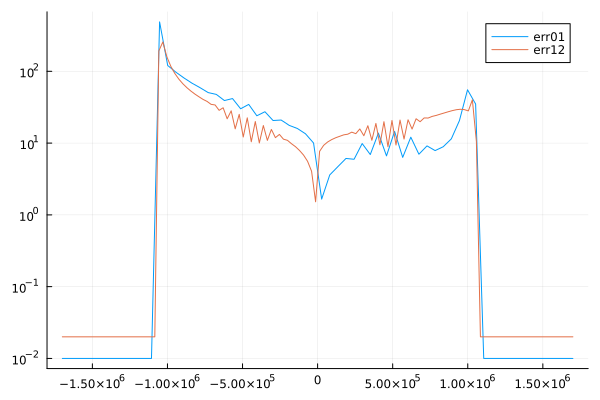

In [9]:
maximum(x0 - x1[2:2:end])
maximum(x1 - x2[2:2:end])

err01 = h0[end] - h1[end][2:2:end]
err12 = h1[end] - h2[end][2:2:end];

plot(x0, abs.(err01 .+ 1e-2), label="err01", yscale = :log10)
plot!(x1, 2*abs.(err12 .+ 1e-2), label="err12", yscale = :log10)

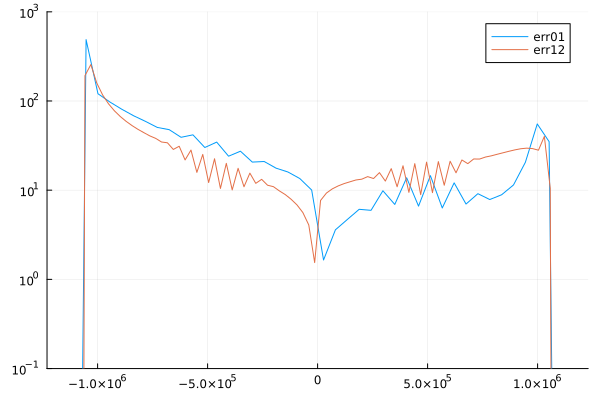

In [10]:
err01_clean = abs.(err01)[abs.(err01) .> 0.0]
x0_clean = x0[abs.(err01) .> 0.0]
err12_clean = abs.(err12)[abs.(err12) .> 0.0]
x1_clean = x1[abs.(err12) .> 0.0]

plot(x0_clean, err01_clean, label="err01", yscale = :log10, ylims=(1e-1,1e3))
plot!(x1_clean, 2*err12_clean, label="err12", yscale = :log10, ylims=(1e-1,1e3))